In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
data = pd.read_csv(r'C:\Users\Neha\Downloads\AI\10th- Ensemble Learning\Machine Learning CAPSTONE PROJECT\HEIGHT & WEIGHT\HeightWeight.csv')

In [4]:
data.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [5]:
data['Weight_kg']=data['Weight(Pounds)']*0.453592  
 
data['Height(Feet.Inches)'] = data['Height(Inches)'] // 12 + (data['Height(Inches)'] % 12) / 10

In [6]:
data.describe()

,Index,Height(Inches),Weight(Pounds),Weight_kg,Height(Feet.Inches)
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421,57.642209,5.795967
std,7217.022701,1.901679,11.660898,5.289290,0.183513
min,1.000000,60.278360,78.014760,35.386871,5.027836
25%,6250.750000,66.704397,119.308675,54.117461,5.670440
50%,12500.500000,67.995700,127.157750,57.677738,5.799570
75%,18750.250000,69.272958,134.892850,61.186318,5.927296
max,25000.000000,75.152800,170.924000,77.529759,6.315280


In [7]:
drop_col=['Index','Height(Inches)','Weight(Pounds)']

data = data.drop(columns=drop_col,axis=1)

In [8]:
data.sample(3)

,Weight_kg,Height(Feet.Inches)
8433,55.268416,5.635334
21246,58.782711,5.793965
23594,57.319106,5.638573


In [9]:
data.shape

(25000, 2)

In [10]:
data.isna().any()

Weight_kg              False
Height(Feet.Inches)    False
dtype: bool

In [11]:
data.dtypes

Weight_kg              float64
Height(Feet.Inches)    float64
dtype: object

In [12]:
data.corr()

,Weight_kg,Height(Feet.Inches)
Weight_kg,1.000000,0.499192
Height(Feet.Inches),0.499192,1.000000


In [13]:
data.describe()

,Weight_kg,Height(Feet.Inches)
count,25000.000000,25000.000000
mean,57.642209,5.795967
std,5.289290,0.183513
min,35.386871,5.027836
25%,54.117461,5.670440
50%,57.677738,5.799570
75%,61.186318,5.927296
max,77.529759,6.315280


# Checking outliers using boxplot

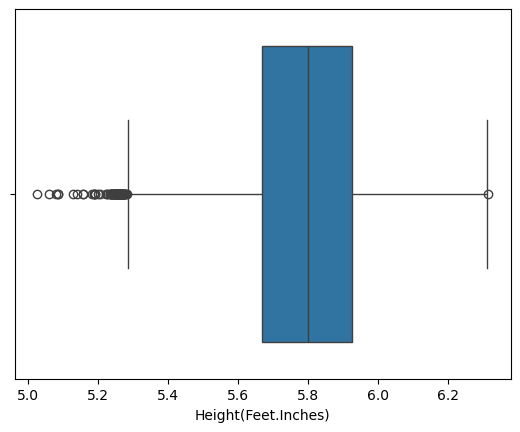

In [14]:
sns.boxplot(x=data['Height(Feet.Inches)'])
plt.show()

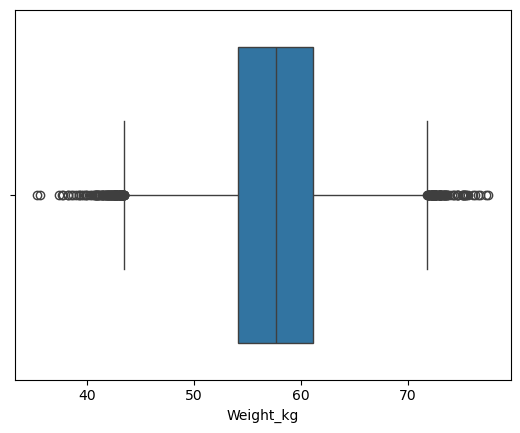

In [15]:
sns.boxplot(x=data['Weight_kg'])
plt.show()

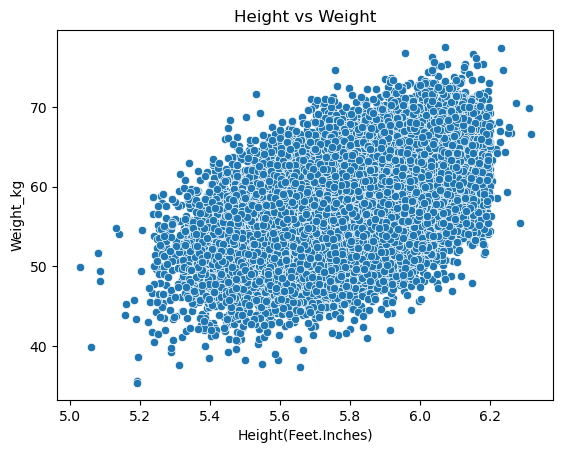

In [17]:
x=data['Height(Feet.Inches)']
y=data['Weight_kg']

sns.scatterplot(x=x,y=y)
plt.title('Height vs Weight')
plt.xlabel('Height(Feet.Inches)')
plt.ylabel('Weight_kg')
plt.show()

In [18]:
data.sample(3)

,Weight_kg,Height(Feet.Inches)
7828,61.022639,5.969329
20722,58.171133,5.846971
6010,55.508729,6.012316


In [19]:
x=data.iloc[:,1]
y=data.iloc[:,0]

In [20]:
x

0        5.578331
1        6.151521
2        5.939874
3        5.821660
4        5.778781
           ...   
24995    5.950215
24996    5.454826
24997    5.469855
24998    5.752918
24999    5.887761
Name: Height(Feet.Inches), Length: 25000, dtype: float64

In [21]:
data.columns[1]

'Height(Feet.Inches)'

In [22]:
data.columns[0]

'Weight_kg'

## Data Scaling[Preprocessing Data]

In [26]:
scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(x.values.reshape(-1,1))

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 ,random_state=0)

In [29]:
print('Shape of trining data')
print(x_train.shape)
print(y_train.shape)

print('Shpae of testing data')
print(x_test.shape)
print(y_test.shape)

Shape of trining data
(20000,)
(20000,)
Shpae of testing data
(5000,)
(5000,)


In [30]:
x_train_2d = x_train.values.reshape(-1, 1)
y_train_2d = y_train.values.reshape(-1, 1)


x_test_2d = x_test.values.reshape(-1, 1)
y_test_2d = y_test.values.reshape(-1, 1)

print("Shape of training data (x):", x_train_2d.shape)
print("Shape of training data (y):", y_train_2d.shape)
print("Shape of testing data (x):", x_test_2d.shape)
print("Shape of testing data (y):", y_test_2d.shape)

Shape of training data (x): (20000, 1)
Shape of training data (y): (20000, 1)
Shape of testing data (x): (5000, 1)
Shape of testing data (y): (5000, 1)


In [31]:
lr = LinearRegression()
lr

LinearRegression()

In [32]:
lr.fit(x_train_2d,y_train_2d)

LinearRegression()

In [34]:
y_pred = lr.predict(x_test_2d)
y_pred[:10]

array([[55.94425481],
       [60.91226889],
       [56.56867714],
       [56.42643564],
       [51.52547113],
       [52.93798976],
       [60.30463034],
       [60.27256006],
       [62.74472434],
       [63.0616341 ]])

In [35]:
y_test_2d[:10]

array([[60.87349789],
       [64.25661383],
       [50.63170805],
       [53.62895327],
       [46.5397639 ],
       [48.20970821],
       [55.81821505],
       [55.03481631],
       [76.60307055],
       [55.98708736]])

In [36]:
mean_squared_error(y_pred,y_test_2d)

21.69730652290755

In [37]:
model_dtr=DecisionTreeRegressor()
model_dtr

DecisionTreeRegressor()

In [38]:
model_dtr.fit(x_train_2d,y_train_2d)

DecisionTreeRegressor()

In [39]:
y_pred_dtr=model_dtr.predict(x_test_2d)
y_pred_dtr[:5]

array([63.37542065, 56.46639802, 56.7162365 , 64.71347169, 57.84078178])

In [40]:
mean_squared_error(y_pred_dtr,y_test_2d)

41.50751860513505

## Random Forest Regressor

In [41]:
model_rfr=RandomForestRegressor()
model_rfr.fit(x_train_2d,y_train_2d)

C:\Users\Neha\Documents\it\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [42]:
y_pred_rfr=(x_test_2d)
y_pred_rfr[:10]

array([[5.675233],
       [6.023626],
       [5.719022],
       [5.709047],
       [5.365356],
       [5.464412],
       [5.981014],
       [5.978765],
       [6.152131],
       [6.174355]])

In [43]:
mean_squared_error(y_pred_rfr,y_test_2d)

2708.30376658499

# Hyperparameter Tuning

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False]
}
model_lr = LinearRegression()

grid_search = GridSearchCV(model_lr, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(x_train_2d, y_train_2d)

print("Best Parameters:", grid_search.best_params_)
print("Best Negative MSE Score:", grid_search.best_score_)

Best Parameters: {'copy_X': True, 'fit_intercept': True}
Best Negative MSE Score: -20.836260216566203


In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

accuracy_scores = cross_val_score(model_lr, x_train_2d, y_train_2d, cv=10, scoring='neg_mean_squared_error')

mse_scores = -accuracy_scores

print("MSE Scores:", mse_scores)

MSE Scores: [21.65411512 21.79844701 20.33072238 21.2128048  21.84713487 20.47547042
 20.38317103 20.4544885  21.45193422 18.76081422]


## Final Model

In [52]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression(fit_intercept=False, copy_X=True)

final_model.fit(x_train_2d,y_train_2d)

LinearRegression(fit_intercept=False)

### Converting to pickle file

In [53]:
import pickle
filename='final_model.pkl'
with open(filename,'wb') as file:
    pickle.dump(final_model,file)

In [55]:
import os

In [56]:
os.path.abspath('final_model.pkl')

'C:\\Users\\Neha\\final_model.pkl'

In [57]:
import pickle
import numpy as np
filename='final_model.pkl'
with open(filename,'rb') as file:
    loaded_model = pickle.load(file)

height_input=6.0
height_input_2d=np.array(height_input).reshape(1,-1)
predicted_weight=loaded_model.predict(height_input_2d)
print('Predicted weight:',predicted_weight[0,0])

Predicted weight: 59.72023785370341
